In [1]:
!pip install tensorflow numpy matplotlib scikit-learn pillow

In [2]:
import tensorflow as tf


In [3]:
from tensorflow.keras import layers, models


In [4]:
import matplotlib.pyplot as plt


In [5]:
import numpy as np


In [6]:
import os

In [7]:
import os

dataset_path = "."

print(os.listdir(dataset_path))

['.ipynb_checkpoints', 'Group_A', 'Group_B', 'Tea Quality Grading.ipynb']


In [8]:
dataset_path = "."

img_size = (224, 224)
batch_size = 32

In [9]:
print(os.listdir(dataset_path))

['.ipynb_checkpoints', 'Group_A', 'Group_B', 'Tea Quality Grading.ipynb']


In [10]:
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))]
        print(folder, "=", len(images), "images")

.ipynb_checkpoints = 0 images
Group_A = 448 images
Group_B = 1282 images


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 1730 files belonging to 2 classes.
Using 1384 files for training.
Found 1730 files belonging to 2 classes.
Using 346 files for validation.


In [12]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['Group_A', 'Group_B']


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [15]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation="softmax")
])

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 896ms/step - accuracy: 0.7565 - loss: 0.6528 - val_accuracy: 0.9480 - val_loss: 0.1430
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 771ms/step - accuracy: 0.9646 - loss: 0.1136 - val_accuracy: 0.8497 - val_loss: 0.5686
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 958ms/step - accuracy: 0.9819 - loss: 0.0722 - val_accuracy: 0.9306 - val_loss: 0.3052
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 954ms/step - accuracy: 0.9913 - loss: 0.0327 - val_accuracy: 0.9798 - val_loss: 0.0793
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 917ms/step - accuracy: 0.9783 - loss: 0.0615 - val_accuracy: 0.8613 - val_loss: 0.8186
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 932ms/step - accuracy: 0.9653 - loss: 0.1317 - val_accuracy: 0.7803 - val_loss: 2.4918
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 950ms/step - accuracy: 0.9444 - loss: 0.1407 - val_accuracy: 0.9653 - val_loss: 0.1166
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 908ms/step - accuracy: 0.9942 - loss: 0.0240 - val_accu

In [18]:
model.save("tea_leaf_group_model.h5")
print("Model saved successfully")

Model saved successfully


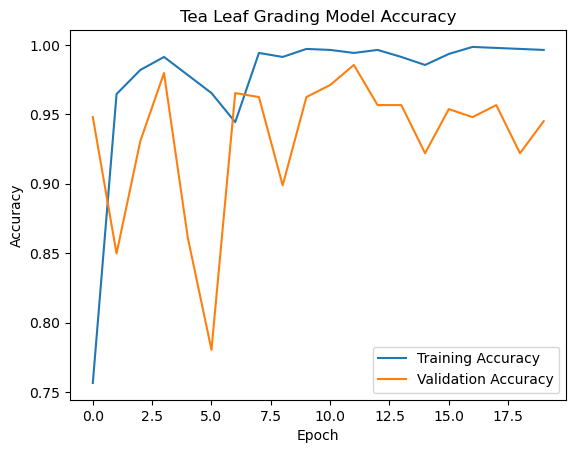

In [30]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Tea Leaf Grading Model Accuracy")
plt.legend()
plt.show()

In [32]:
!pip install opencv-python scikit-learn pandas numpy matplotlib

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.2 MB/s eta 0:00:34
    --------------------------------------- 0.8/40.2 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.0/40.2 MB 1.2 MB/s eta 0:00:32
   - -------------------------------------- 1.3/40.2 MB 1.3 MB/s eta 0:00:31
   - -------------------------------------- 1.6/40.2 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.8/40.2 MB 1.4 MB/s eta 0:00:28
   -- ------------------------------------- 2.4/40.2 MB 1.4 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/40.2 MB 1.4 MB/s eta 0:00:27
   --- ------------------------------------ 3.1/40.2 MB 1.5 MB/s eta 0:00:25
   --- ------------------------------------ 3.4/40.2 MB 1.5 MB/s eta 0:00:24
   --- -------------

In [33]:
import os


In [34]:
import cv2


In [35]:
import numpy as np


In [36]:
import pandas as pd


In [37]:
from sklearn.model_selection import train_test_split


In [38]:
from sklearn.ensemble import RandomForestClassifier


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
dataset_path = "."

classes = ["Group_A", "Group_B"]

label_map = {
    "Group_A": "Grade_A_Good",
    "Group_B": "Grade_B_Bad"
}

In [41]:
def extract_features(image_path):
    # Read image
    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize image
    img = cv2.resize(img, (224, 224))

    # Convert BGR to RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # -------------------------
    # 1. COLOR FEATURES
    # -------------------------
    mean_red = np.mean(rgb[:, :, 0])
    mean_green = np.mean(rgb[:, :, 1])
    mean_blue = np.mean(rgb[:, :, 2])

    # Convert to HSV for better color analysis
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_hue = np.mean(hsv[:, :, 0])
    mean_saturation = np.mean(hsv[:, :, 1])
    mean_value = np.mean(hsv[:, :, 2])

    # -------------------------
    # 2. SHAPE + SIZE FEATURES
    # -------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold image
    _, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)

        x, y, w, h = cv2.boundingRect(largest_contour)

        aspect_ratio = w / h if h != 0 else 0

        # Roundness calculation
        if perimeter != 0:
            roundness = (4 * np.pi * area) / (perimeter ** 2)
        else:
            roundness = 0

    else:
        area = 0
        perimeter = 0
        w = 0
        h = 0
        aspect_ratio = 0
        roundness = 0

    return [
        mean_red,
        mean_green,
        mean_blue,
        mean_hue,
        mean_saturation,
        mean_value,
        area,
        perimeter,
        w,
        h,
        aspect_ratio,
        roundness
    ]

In [42]:
data = []

for class_folder in classes:
    folder_path = os.path.join(dataset_path, class_folder)

    for image_name in os.listdir(folder_path):
        if image_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(folder_path, image_name)

            features = extract_features(image_path)

            if features is not None:
                data.append(features + [class_folder])

columns = [
    "mean_red",
    "mean_green",
    "mean_blue",
    "mean_hue",
    "mean_saturation",
    "mean_value",
    "area",
    "perimeter",
    "width",
    "height",
    "aspect_ratio",
    "roundness",
    "label"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,mean_red,mean_green,mean_blue,mean_hue,mean_saturation,mean_value,area,perimeter,width,height,aspect_ratio,roundness,label
0,185.772381,198.576730,174.031669,65.109973,51.650849,198.696907,10857.0,609.269112,180,98,1.836735,0.367537,Group_A
1,181.341558,194.960280,167.819794,66.072864,58.352918,195.101184,13012.0,652.700572,214,90,2.377778,0.383819,Group_A
2,213.384427,213.407585,207.260204,28.271066,12.559251,214.000478,2066.0,224.107645,71,70,1.014286,0.516924,Group_A
3,214.701849,214.931103,208.424187,29.112903,12.774275,215.453444,2019.5,234.752307,36,102,0.352941,0.460505,Group_A
4,211.213010,213.073800,205.715980,35.294882,14.058952,213.206653,2526.5,271.806129,68,100,0.680000,0.429745,Group_A


In [43]:
print(df.shape)
print(df["label"].value_counts())

(1730, 13)
label
Group_B    1282
Group_A     448
Name: count, dtype: int64


In [44]:
X = df.drop("label", axis=1)
y = df["label"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred = model_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 96.82 %
              precision    recall  f1-score   support

     Group_A       0.98      0.90      0.94        90
     Group_B       0.97      0.99      0.98       256

    accuracy                           0.97       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.97      0.97      0.97       346

[[ 81   9]
 [  2 254]]


In [58]:
import joblib

joblib.dump(model_rf, "tea_feature_grading_model.pkl")

print("Feature-based model saved successfully")

Feature-based model saved successfully


In [59]:
from tensorflow.keras.preprocessing import image


In [60]:
import numpy as np


In [61]:
import matplotlib.pyplot as plt


In [62]:
img_path = "dr_0_1304.jpg"


In [63]:
img = image.load_img(img_path, target_size=(224, 224))


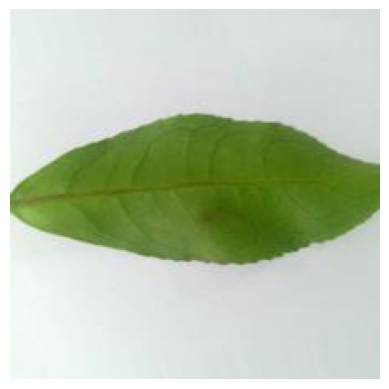

In [64]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [65]:
img_array = image.img_to_array(img)


In [66]:
img_array = np.expand_dims(img_array, axis=0)


In [67]:
img_array = img_array / 255.0


In [68]:
prediction = model.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [69]:
predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

In [70]:
grade_meaning = {
    "Group_A": "Grade A - High Quality / Good",
    "Group_B": "Grade B - Low Quality / Bad"
}

In [71]:
print("Predicted Class:", predicted_class)
print("Predicted Grade:", grade_meaning[predicted_class])
print("Confidence:", round(confidence, 2), "%")

Predicted Class: Group_B
Predicted Grade: Grade B - Low Quality / Bad
Confidence: 100.0 %
